# Sensor Trace Expansion Analysis (GPU)

Same analysis as *Sensor trace expansion.ipynb* but with the linear SVM
implemented as a PyTorch linear layer + Crammer–Singer hinge loss, running
entirely on MPS/CUDA.  The HD projection (`W_hd`, `x_hd`) also stays on device.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.model_selection import train_test_split
from tools import load
from math import comb
import torch
import pickle
import os


def backward_diff_array(y, h, n):
    """n-th backward finite difference (zero-padded to preserve length)."""
    coeffs = np.array([(-1)**k * comb(n, k) for k in range(n + 1)])
    raw = np.convolve(y, coeffs, mode='valid') / h**n
    return np.concatenate([np.zeros(n), raw])


device = torch.device('mps' if torch.backends.mps.is_available() else
                       'cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: mps


In [2]:
filename = '1_600_20'
sensor_data, sequence, times_sec, sequence_sec = load(filename, reduced=True)
h = np.median(np.diff(times_sec))
n_sensors = sensor_data.shape[1]

# Build labels from sequence
labels = np.zeros_like(times_sec)
for i in range(len(sequence_sec)):
    try:
        flag = (times_sec > sequence_sec[i]) & (times_sec < sequence_sec[i + 1])
    except IndexError:
        flag = (times_sec > sequence_sec[i])
    labels[flag] = int(sequence[i][1])

labeled_mask = labels > 0
y_labels = labels[labeled_mask].astype(int)

print(f"Sensor data: {sensor_data.shape}  ({n_sensors} sensors)")
print(f"Labeled samples: {np.sum(labeled_mask)}")
print(f"Sampling interval h = {h:.4f} s")

Sensor data: (11691, 8)  (8 sensors)
Labeled samples: 11392
Sampling interval h = 1.0000 s


In [3]:
def expand_with_derivatives(data, h, max_order):
    """Append backward differences of orders 1..max_order (8 cols each)."""
    if max_order == 0:
        return data.copy()
    derivs = []
    for order in range(1, max_order + 1):
        d = np.apply_along_axis(
            lambda col: backward_diff_array(col, h, order), axis=0, arr=data)
        derivs.append(d)
    return np.hstack([data] + derivs)


def expand_with_ratios(data, n_pairs, pairs_pool):
    """Append n_pairs ratio columns: sensor[i] / sensor[j]."""
    if n_pairs == 0:
        return data.copy()
    cols = [data[:, i] / (data[:, j] + 1e-8) for i, j in pairs_pool[:n_pairs]]
    return np.hstack([data, np.column_stack(cols)])


def expand_with_differences(data, n_pairs, pairs_pool):
    """Append n_pairs difference columns: sensor[i] - sensor[j]."""
    if n_pairs == 0:
        return data.copy()
    cols = [data[:, i] - data[:, j] for i, j in pairs_pool[:n_pairs]]
    return np.hstack([data, np.column_stack(cols)])


# Pre-generate pair pools (ordered pairs, fixed seed)
rng_pairs = np.random.default_rng(0)
all_ordered_pairs = [(i, j) for i in range(n_sensors) for j in range(n_sensors) if i != j]
ratio_pairs = [all_ordered_pairs[i] for i in rng_pairs.permutation(len(all_ordered_pairs))]
diff_pairs  = [all_ordered_pairs[i] for i in rng_pairs.permutation(len(all_ordered_pairs))]

print(f"Available ordered pairs: {len(all_ordered_pairs)}")

Available ordered pairs: 56


In [4]:
# HD projection parameters
n_hd = 10_000
p_hd_sweep = [0.05, 0.1, 0.2, 0.4]
n_repeats = 10
n_samples_mse = 100

# Sweep values
deriv_orders = [0, 1, 2, 3, 4]           # n_dense = 8, 16, 24, 32, 40
pair_counts  = [0, 4, 8, 16, 24, 32]     # n_dense = 8, 12, 16, 24, 32, 40

# Saves
pkl_dense = 'data/acc_dense_results.pkl'
pkl_hd = 'data/acc_hd_results.pkl'

In [5]:
# Remap labels 1,2,3 -> 0,1,2 for indexing
y_labels_0 = y_labels - 1
n_classes = int(y_labels_0.max()) + 1


def train_linear_svm(X, y, n_classes, C=1.0, lr=1e-3, n_epochs=200):
    """Multiclass linear SVM (Crammer-Singer) on GPU.

    Minimises  (1/n) sum_i sum_{j!=y_i} max(0, 1 - s_{y_i} + s_j)
            + 1/(2C) ||W||^2
    """
    n, d = X.shape
    W = torch.zeros(n_classes, d, device=device, requires_grad=True)
    b = torch.zeros(n_classes, device=device, requires_grad=True)

    opt = torch.optim.Adam([
        {'params': W, 'weight_decay': 1.0 / (C * n)},
        {'params': b, 'weight_decay': 0.0}
    ], lr=lr)

    idx = torch.arange(n, device=device)

    for _ in range(n_epochs):
        scores = X @ W.T + b                          # (n, C)
        correct_scores = scores[idx, y].unsqueeze(1)   # (n, 1)
        margins = scores - correct_scores + 1.0        # (n, C)
        # mask out the correct class so it doesn't contribute to the loss
        mask = torch.ones_like(scores)
        mask[idx, y] = 0.0
        loss = (torch.clamp(margins, min=0) * mask).sum() / n

        opt.zero_grad()
        loss.backward()
        opt.step()

    return W.detach(), b.detach()


@torch.no_grad()
def score_linear_svm(X, y, W, b):
    """Classification accuracy."""
    preds = (X @ W.T + b).argmax(dim=1)
    return (preds == y).float().mean().item()

## 1. Linear SVM on $x_{dense}$ (baseline)

Classify directly from the expanded sensor features — no HD projection.
This establishes a baseline for comparison with the $x_{hd}$ results below.

In [6]:
if os.path.exists(pkl_dense):
    with open(pkl_dense, 'rb') as f:
        saved = pickle.load(f)
    acc_dense_deriv  = saved['derivatives']
    acc_dense_ratios = saved['ratios']
    acc_dense_diffs  = saved['differences']
    print(f"Loaded x_dense results from {pkl_dense}")
else:
    def run_acc_sweep_dense(expand_fn, sweep_vals, expand_kwargs, label):
        """Run classification accuracy sweep on x_dense (no HD projection)."""
        results = []
        for val in sweep_vals:
            x_exp = expand_fn(sensor_data, **{expand_kwargs: val})
            x_labeled = x_exp[labeled_mask]
            n_dense = x_labeled.shape[1]

            x_t = torch.tensor(x_labeled, dtype=torch.float32, device=device)
            y_t = torch.tensor(y_labels_0, dtype=torch.long, device=device)

            trial_accs = []
            for seed in range(n_repeats):
                indices = np.arange(len(y_labels_0))
                tr_idx, te_idx = train_test_split(
                    indices, test_size=0.2, random_state=seed, stratify=y_labels_0)
                tr_idx = torch.tensor(tr_idx, device=device)
                te_idx = torch.tensor(te_idx, device=device)

                W, b = train_linear_svm(x_t[tr_idx], y_t[tr_idx], n_classes)
                trial_accs.append(score_linear_svm(x_t[te_idx], y_t[te_idx], W, b))

            results.append((n_dense, np.mean(trial_accs), np.std(trial_accs)))
            print(f"{label} {expand_kwargs}={val}: n_dense={n_dense}, acc={np.mean(trial_accs):.4f}")
            del x_t
        return results

    acc_dense_deriv = run_acc_sweep_dense(
        lambda data, max_order: expand_with_derivatives(data, h, max_order),
        deriv_orders, 'max_order', 'Derivatives')

    acc_dense_ratios = run_acc_sweep_dense(
        lambda data, n_pairs: expand_with_ratios(data, n_pairs, ratio_pairs),
        pair_counts, 'n_pairs', 'Ratios')

    acc_dense_diffs = run_acc_sweep_dense(
        lambda data, n_pairs: expand_with_differences(data, n_pairs, diff_pairs),
        pair_counts, 'n_pairs', 'Differences')

Loaded x_dense results from data/acc_dense_results.pkl


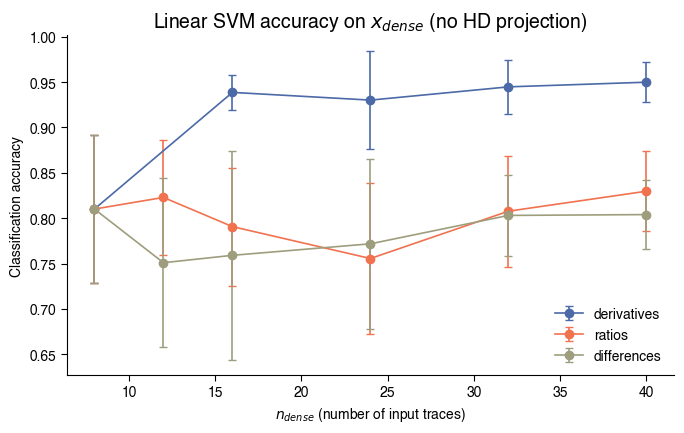

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for label, data in [('derivatives', acc_dense_deriv), ('ratios', acc_dense_ratios),
                     ('differences', acc_dense_diffs)]:
    x, y, e = zip(*data)
    ax.errorbar(x, y, yerr=e, marker='o', label=label, capsize=3)

ax.set_xlabel('$n_{dense}$ (number of input traces)')
ax.set_ylabel('Classification accuracy')
ax.set_title('Linear SVM accuracy on $x_{dense}$ (no HD projection)')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## 2. MSE of $x_{hd}$ distribution vs $\mathcal{N}(0, 1)$

For each sample, recast $x_{hd}$ to zero mean and unit variance, bin into a
histogram, and compare with the standard normal PDF.

In [8]:
def compute_mse_normality(x_hd, n_samples=100, rng=None):
    """Mean MSE between per-row histograms of recast x_hd and N(0,1)."""
    if rng is None:
        rng = np.random.default_rng()
    idx = rng.choice(x_hd.shape[0], size=min(n_samples, x_hd.shape[0]), replace=False)
    mses = []
    for i in idx:
        vals = x_hd[i]
        mu, sigma = np.mean(vals), np.std(vals)
        if sigma < 1e-10:
            continue
        recast = (vals - mu) / sigma
        counts, edges = np.histogram(recast, bins=100, range=(-5, 5), density=True)
        centers = 0.5 * (edges[:-1] + edges[1:])
        mses.append(np.mean((counts - norm.pdf(centers)) ** 2))
    return np.mean(mses) if mses else np.nan


def run_mse_sweep(expand_fn, sweep_vals, expand_kwargs, label, p_hd):
    """Run MSE sweep for a given expansion function and p_hd."""
    results = []
    for val in sweep_vals:
        x_exp = expand_fn(sensor_data, **{expand_kwargs: val})
        n_dense = x_exp.shape[1]
        trial_mses = []
        for seed in range(n_repeats):
            rng = np.random.default_rng(seed)
            W = rng.binomial(1, p_hd, size=(n_hd, n_dense))
            x_hd = x_exp @ W.T
            trial_mses.append(compute_mse_normality(x_hd, n_samples_mse, rng))
        results.append((n_dense, np.mean(trial_mses), np.std(trial_mses)))
        print(f"  {label} {expand_kwargs}={val}: n_dense={n_dense}, MSE={np.mean(trial_mses):.4f}")
    return results


mse_results = {}
for p_hd in p_hd_sweep:
    print(f"\n--- p_hd = {p_hd} ---")
    mse_results[p_hd] = {
        'derivatives': run_mse_sweep(
            lambda data, max_order: expand_with_derivatives(data, h, max_order),
            deriv_orders, 'max_order', 'Derivatives', p_hd),
        'ratios': run_mse_sweep(
            lambda data, n_pairs: expand_with_ratios(data, n_pairs, ratio_pairs),
            pair_counts, 'n_pairs', 'Ratios', p_hd),
        'differences': run_mse_sweep(
            lambda data, n_pairs: expand_with_differences(data, n_pairs, diff_pairs),
            pair_counts, 'n_pairs', 'Differences', p_hd),
    }


--- p_hd = 0.05 ---
  Derivatives max_order=0: n_dense=8, MSE=0.4209
  Derivatives max_order=1: n_dense=16, MSE=0.3709
  Derivatives max_order=2: n_dense=24, MSE=0.3638
  Derivatives max_order=3: n_dense=32, MSE=0.3507
  Derivatives max_order=4: n_dense=40, MSE=0.3385
  Ratios n_pairs=0: n_dense=8, MSE=0.4209
  Ratios n_pairs=4: n_dense=12, MSE=0.4199
  Ratios n_pairs=8: n_dense=16, MSE=0.4210
  Ratios n_pairs=16: n_dense=24, MSE=0.4177
  Ratios n_pairs=24: n_dense=32, MSE=0.4186
  Ratios n_pairs=32: n_dense=40, MSE=0.4135
  Differences n_pairs=0: n_dense=8, MSE=0.4209
  Differences n_pairs=4: n_dense=12, MSE=0.2866
  Differences n_pairs=8: n_dense=16, MSE=0.2010
  Differences n_pairs=16: n_dense=24, MSE=0.0975
  Differences n_pairs=24: n_dense=32, MSE=0.0477
  Differences n_pairs=32: n_dense=40, MSE=0.0263

--- p_hd = 0.1 ---
  Derivatives max_order=0: n_dense=8, MSE=0.1859
  Derivatives max_order=1: n_dense=16, MSE=0.1563
  Derivatives max_order=2: n_dense=24, MSE=0.1528
  Derivativ

## 3. Linear SVM accuracy on $x_{hd}$ (GPU)

Multiclass linear SVM via Crammer–Singer hinge loss, trained with Adam on
MPS/CUDA.  The HD random projection also runs on device.

In [9]:
if os.path.exists(pkl_hd):
    with open(pkl_hd, 'rb') as f:
        acc_results = pickle.load(f)
    print(f"Loaded x_hd results from {pkl_hd}")
else:
    def run_acc_sweep_gpu(expand_fn, sweep_vals, expand_kwargs, label, p_hd):
        """Run classification accuracy sweep entirely on GPU."""
        results = []
        for val in sweep_vals:
            x_exp = expand_fn(sensor_data, **{expand_kwargs: val})
            x_labeled = x_exp[labeled_mask]
            n_dense = x_labeled.shape[1]

            x_t = torch.tensor(x_labeled, dtype=torch.float32, device=device)
            y_t = torch.tensor(y_labels_0, dtype=torch.long, device=device)

            trial_accs = []
            for seed in range(n_repeats):
                torch.manual_seed(seed)
                W_hd = torch.bernoulli(torch.full((n_hd, n_dense), p_hd, device=device))
                x_hd = x_t @ W_hd.T

                indices = np.arange(len(y_labels_0))
                tr_idx, te_idx = train_test_split(
                    indices, test_size=0.2, random_state=seed, stratify=y_labels_0)
                tr_idx = torch.tensor(tr_idx, device=device)
                te_idx = torch.tensor(te_idx, device=device)

                W, b = train_linear_svm(x_hd[tr_idx], y_t[tr_idx], n_classes)
                trial_accs.append(score_linear_svm(x_hd[te_idx], y_t[te_idx], W, b))

                del W_hd, x_hd

            results.append((n_dense, np.mean(trial_accs), np.std(trial_accs)))
            print(f"  {label} {expand_kwargs}={val}: n_dense={n_dense}, acc={np.mean(trial_accs):.4f}")
            del x_t
        return results

    acc_results = {}
    for p_hd in p_hd_sweep:
        print(f"\n--- p_hd = {p_hd} ---")
        acc_results[p_hd] = {
            'derivatives': run_acc_sweep_gpu(
                lambda data, max_order: expand_with_derivatives(data, h, max_order),
                deriv_orders, 'max_order', 'Derivatives', p_hd),
            'ratios': run_acc_sweep_gpu(
                lambda data, n_pairs: expand_with_ratios(data, n_pairs, ratio_pairs),
                pair_counts, 'n_pairs', 'Ratios', p_hd),
            'differences': run_acc_sweep_gpu(
                lambda data, n_pairs: expand_with_differences(data, n_pairs, diff_pairs),
                pair_counts, 'n_pairs', 'Differences', p_hd),
        }

Loaded x_hd results from data/acc_hd_results.pkl


In [10]:
# Save results to pickle (delete the files to force re-computation)
with open(pkl_dense, 'wb') as f:
    pickle.dump({'derivatives': acc_dense_deriv,
                 'ratios': acc_dense_ratios,
                 'differences': acc_dense_diffs}, f)

with open(pkl_hd, 'wb') as f:
    pickle.dump(acc_results, f)

print(f"Saved x_dense results to {pkl_dense}")
print(f"Saved x_hd results to {pkl_hd}")

Saved x_dense results to data/acc_dense_results.pkl
Saved x_hd results to data/acc_hd_results.pkl


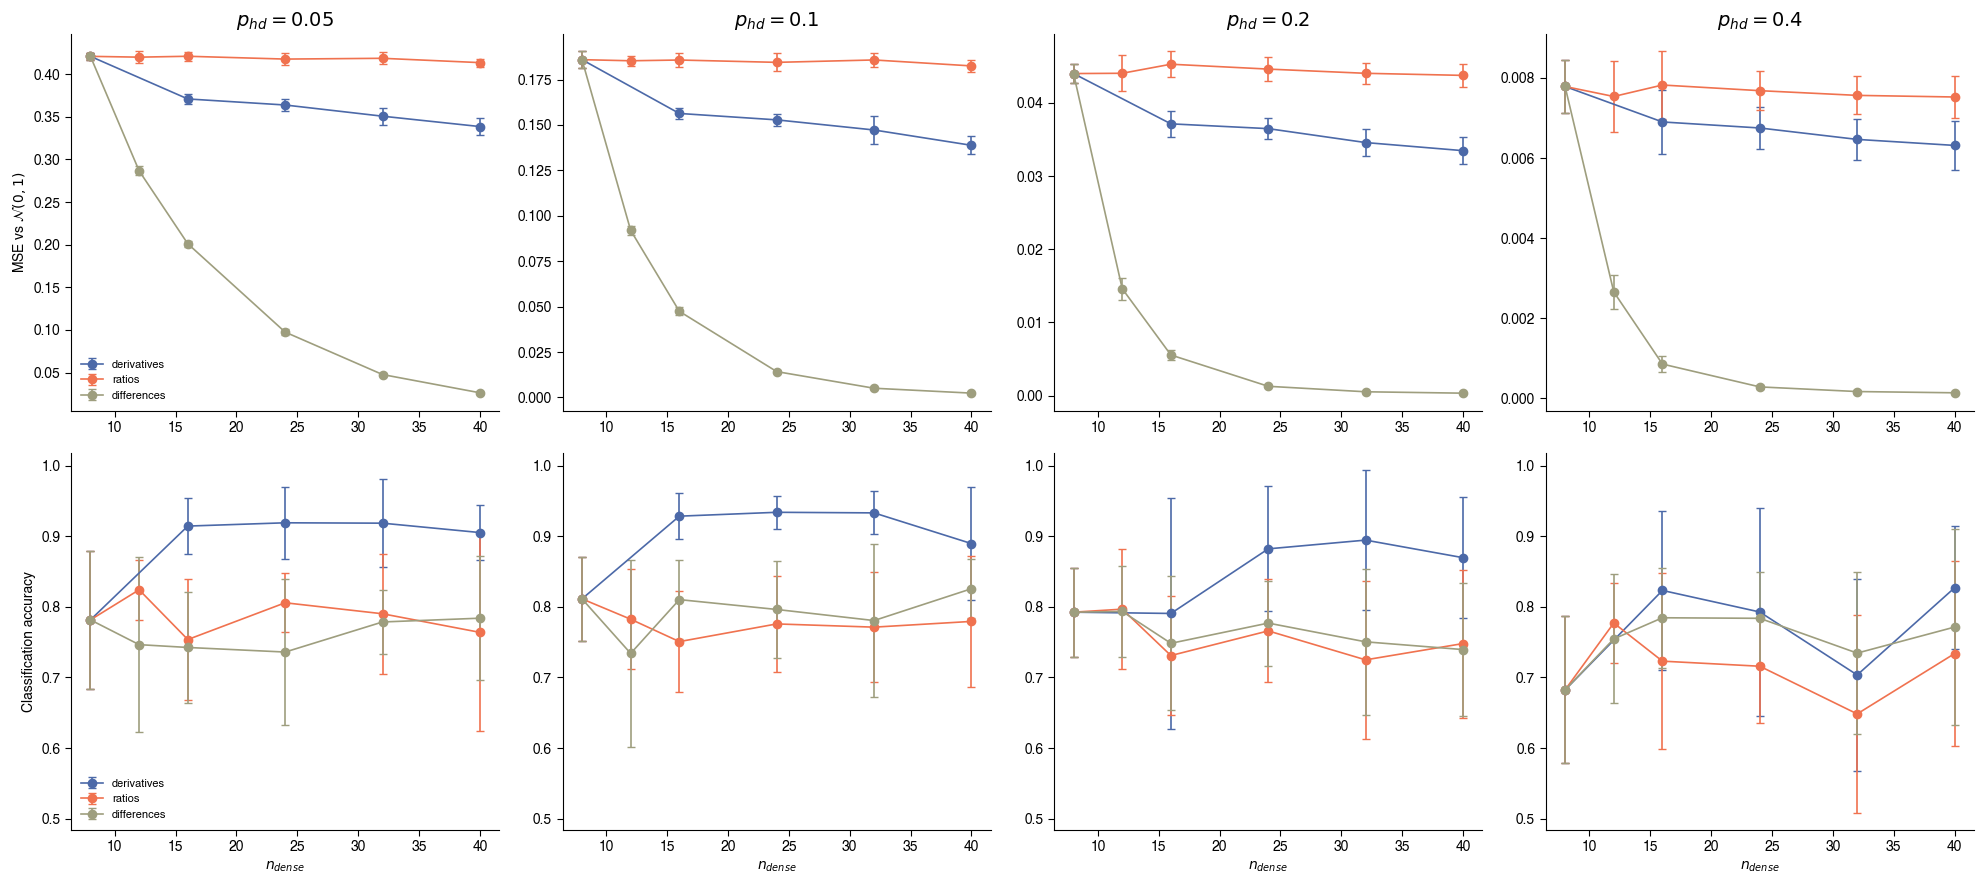

In [11]:
fig, axes = plt.subplots(2, len(p_hd_sweep), figsize=(5 * len(p_hd_sweep), 9),
                         sharey=False)

for j, p in enumerate(p_hd_sweep):
    # Top row: MSE (independent y-axes)
    ax = axes[0, j]
    for label, data in mse_results[p].items():
        x, y, e = zip(*data)
        ax.errorbar(x, y, yerr=e, marker='o', label=label, capsize=3)
    ax.set_title(f'$p_{{hd}} = {p}$')
    ax.spines[['top', 'right']].set_visible(False)
    if j == 0:
        ax.set_ylabel('MSE vs $\\mathcal{N}(0, 1)$')
        ax.legend(frameon=False, fontsize=8)

    # Bottom row: accuracy (shared y-axis)
    ax = axes[1, j]
    for label, data in acc_results[p].items():
        x, y, e = zip(*data)
        ax.errorbar(x, y, yerr=e, marker='o', label=label, capsize=3)
    ax.set_xlabel('$n_{dense}$')
    ax.spines[['top', 'right']].set_visible(False)
    if j == 0:
        ax.set_ylabel('Classification accuracy')
        ax.legend(frameon=False, fontsize=8)

# Share y-axis only on bottom row
for ax in axes[1, 1:]:
    ax.sharey(axes[1, 0])

plt.tight_layout()
plt.show()

## 4. Mixed expansions (8, 16, 24 and 32 traces)

Compare different ways to compose the input features at fixed total dimensionality.
All configs include the 8 raw sensors as a common base, then add extra traces via
derivatives, ratios (R), and/or differences (D).

In [12]:
n_repeats = 100

# Reusable building blocks
x_d1  = expand_with_derivatives(sensor_data, h, max_order=1)   # 16 cols
x_d12 = expand_with_derivatives(sensor_data, h, max_order=2)   # 24 cols

r8  = np.column_stack([sensor_data[:, i] / (sensor_data[:, j] + 1e-8) for i, j in ratio_pairs[:8]])
r12 = np.column_stack([sensor_data[:, i] / (sensor_data[:, j] + 1e-8) for i, j in ratio_pairs[:12]])
d8  = np.column_stack([sensor_data[:, i] - sensor_data[:, j] for i, j in diff_pairs[:8]])
d12 = np.column_stack([sensor_data[:, i] - sensor_data[:, j] for i, j in diff_pairs[:12]])

# --- 8-trace config ---
configs_8 = {
    'raw':                sensor_data.copy(),
}

# --- 16-trace configs ---
configs_16 = {
    '∂¹':                 x_d1,
    '8R':                 np.hstack([sensor_data, r8]),
    '8D':                 np.hstack([sensor_data, d8]),
}

# --- 24-trace configs ---
configs_24 = {
    '∂¹+∂²':             x_d12,
    '∂¹ + 8D':            np.hstack([x_d1, d8]),
    '∂¹ + 8R':            np.hstack([x_d1, r8]),
    '8D + 8R':             np.hstack([sensor_data, d8, r8]),
}

# --- 32-trace configs ---
x_d123 = expand_with_derivatives(sensor_data, h, max_order=3)  # 32 cols

configs_32 = {
    '∂¹+∂²+∂³':           x_d123,
    '∂¹+∂² + 8R':          np.hstack([x_d12, r8]),
    '∂¹+∂² + 8D':          np.hstack([x_d12, d8]),
    '∂¹ + 8R + 8D':        np.hstack([x_d1, r8, d8]),
    '12R + 12D':            np.hstack([sensor_data, r12, d12]),
}

configs = {**configs_8, **configs_16, **configs_24, **configs_32}

for name, x in configs.items():
    print(f"{name}: {x.shape}")


# Compute x_dense accuracy for each config
table = {}
for name, x_exp in configs.items():
    x_labeled = x_exp[labeled_mask]
    x_t = torch.tensor(x_labeled, dtype=torch.float32, device=device)
    y_t = torch.tensor(y_labels_0, dtype=torch.long, device=device)

    accs = []
    for seed in range(n_repeats):
        indices = np.arange(len(y_labels_0))
        tr_idx, te_idx = train_test_split(
            indices, test_size=0.2, random_state=seed, stratify=y_labels_0)
        tr_idx = torch.tensor(tr_idx, device=device)
        te_idx = torch.tensor(te_idx, device=device)

        W, b = train_linear_svm(x_t[tr_idx], y_t[tr_idx], n_classes)
        accs.append(score_linear_svm(x_t[te_idx], y_t[te_idx], W, b))

    table[name] = (np.mean(accs), np.std(accs))
    print(f"{name}: {np.mean(accs):.4f} ± {np.std(accs):.4f}")

# ---- mix_100_20_1 ----
print("\n--- mix_100_20_1 ---")
sensor_data_mix, sequence_mix, times_sec_mix, sequence_sec_mix = load('mix_100_20_1', reduced=True)
h_mix = np.median(np.diff(times_sec_mix))

labels_mix = np.zeros_like(times_sec_mix)
for i in range(len(sequence_sec_mix)):
    try:
        flag = (times_sec_mix > sequence_sec_mix[i]) & (times_sec_mix < sequence_sec_mix[i + 1])
    except IndexError:
        flag = (times_sec_mix > sequence_sec_mix[i])
    labels_mix[flag] = int(sequence_mix[i][1])

labeled_mask_mix = labels_mix > 0
y_labels_mix = labels_mix[labeled_mask_mix].astype(int)
y_labels_0_mix = y_labels_mix - 1
n_classes_mix = int(y_labels_0_mix.max()) + 1

print(f"Sensor data: {sensor_data_mix.shape}")
print(f"Labeled samples: {np.sum(labeled_mask_mix)}")

# Building blocks for mix
x_d1_mix   = expand_with_derivatives(sensor_data_mix, h_mix, max_order=1)
x_d12_mix  = expand_with_derivatives(sensor_data_mix, h_mix, max_order=2)
x_d123_mix = expand_with_derivatives(sensor_data_mix, h_mix, max_order=3)
r8_mix  = np.column_stack([sensor_data_mix[:, i] / (sensor_data_mix[:, j] + 1e-8) for i, j in ratio_pairs[:8]])
r12_mix = np.column_stack([sensor_data_mix[:, i] / (sensor_data_mix[:, j] + 1e-8) for i, j in ratio_pairs[:12]])
d8_mix  = np.column_stack([sensor_data_mix[:, i] - sensor_data_mix[:, j] for i, j in diff_pairs[:8]])
d12_mix = np.column_stack([sensor_data_mix[:, i] - sensor_data_mix[:, j] for i, j in diff_pairs[:12]])

configs_8_mix  = {'raw': sensor_data_mix.copy()}
configs_16_mix = {
    '∂¹':    x_d1_mix,
    '8R':    np.hstack([sensor_data_mix, r8_mix]),
    '8D':    np.hstack([sensor_data_mix, d8_mix]),
}
configs_24_mix = {
    '∂¹+∂²':    x_d12_mix,
    '∂¹ + 8D':  np.hstack([x_d1_mix, d8_mix]),
    '∂¹ + 8R':  np.hstack([x_d1_mix, r8_mix]),
    '8D + 8R':  np.hstack([sensor_data_mix, d8_mix, r8_mix]),
}
configs_32_mix = {
    '∂¹+∂²+∂³':    x_d123_mix,
    '∂¹+∂² + 8R':  np.hstack([x_d12_mix, r8_mix]),
    '∂¹+∂² + 8D':  np.hstack([x_d12_mix, d8_mix]),
    '∂¹ + 8R + 8D': np.hstack([x_d1_mix, r8_mix, d8_mix]),
    '12R + 12D':    np.hstack([sensor_data_mix, r12_mix, d12_mix]),
}
configs_mix = {**configs_8_mix, **configs_16_mix, **configs_24_mix, **configs_32_mix}

table_mix = {}
for name, x_exp in configs_mix.items():
    x_labeled = x_exp[labeled_mask_mix]
    x_t = torch.tensor(x_labeled, dtype=torch.float32, device=device)
    y_t = torch.tensor(y_labels_0_mix, dtype=torch.long, device=device)

    accs = []
    for seed in range(n_repeats):
        indices = np.arange(len(y_labels_0_mix))
        tr_idx, te_idx = train_test_split(
            indices, test_size=0.2, random_state=seed, stratify=y_labels_0_mix)
        tr_idx = torch.tensor(tr_idx, device=device)
        te_idx = torch.tensor(te_idx, device=device)

        W, b = train_linear_svm(x_t[tr_idx], y_t[tr_idx], n_classes_mix)
        accs.append(score_linear_svm(x_t[te_idx], y_t[te_idx], W, b))

    table_mix[name] = (np.mean(accs), np.std(accs))
    print(f"{name}: {np.mean(accs):.4f} ± {np.std(accs):.4f}")

raw: (11691, 8)
∂¹: (11691, 16)
8R: (11691, 16)
8D: (11691, 16)
∂¹+∂²: (11691, 24)
∂¹ + 8D: (11691, 24)
∂¹ + 8R: (11691, 24)
8D + 8R: (11691, 24)
∂¹+∂²+∂³: (11691, 32)
∂¹+∂² + 8R: (11691, 32)
∂¹+∂² + 8D: (11691, 32)
∂¹ + 8R + 8D: (11691, 32)
12R + 12D: (11691, 32)
raw: 0.7929 ± 0.0829
∂¹: 0.9191 ± 0.0688
8R: 0.8096 ± 0.0604
8D: 0.7993 ± 0.0726
∂¹+∂²: 0.9326 ± 0.0572
∂¹ + 8D: 0.9151 ± 0.0497
∂¹ + 8R: 0.9289 ± 0.0454
8D + 8R: 0.7958 ± 0.0686
∂¹+∂²+∂³: 0.9376 ± 0.0517
∂¹+∂² + 8R: 0.9384 ± 0.0442
∂¹+∂² + 8D: 0.9209 ± 0.0542
∂¹ + 8R + 8D: 0.9147 ± 0.0568
12R + 12D: 0.7874 ± 0.0757

--- mix_100_20_1 ---
Sensor data: (11445, 8)
Labeled samples: 11386
raw: 0.3899 ± 0.0539
∂¹: 0.5977 ± 0.0744
8R: 0.3884 ± 0.0559
8D: 0.3893 ± 0.0564
∂¹+∂²: 0.6218 ± 0.0738
∂¹ + 8D: 0.5719 ± 0.0791
∂¹ + 8R: 0.6027 ± 0.0700
8D + 8R: 0.3798 ± 0.0589
∂¹+∂²+∂³: 0.6112 ± 0.0742
∂¹+∂² + 8R: 0.6220 ± 0.0737
∂¹+∂² + 8D: 0.5754 ± 0.0818
∂¹ + 8R + 8D: 0.5625 ± 0.0726
12R + 12D: 0.3683 ± 0.0583


In [13]:
# Display as a single table with group separations
from IPython.display import HTML, display

groups = [
    ('8 traces', configs_8),
    ('16 traces', configs_16),
    ('24 traces', configs_24),
    ('32 traces', configs_32),
]

rows_html = []
for group_label, cfg_dict in groups:
    for i, name in enumerate(cfg_dict):
        m1, s1 = table[name]
        m2, s2 = table_mix[name]
        border = ' style="border-top: 2px solid #888;"' if i == 0 else ''
        rows_html.append(
            f'<tr{border}><td>{name}</td>'
            f'<td style="text-align:center;">{cfg_dict[name].shape[1]}</td>'
            f'<td>{m1:.3f} &plusmn; {s1:.3f}</td>'
            f'<td>{m2:.3f} &plusmn; {s2:.3f}</td></tr>'
        )

html_table = f'''<table style="border-collapse:collapse;">
<thead>
<tr>
  <th rowspan="2" style="text-align:left; vertical-align:bottom;">Expansion</th>
  <th rowspan="2" style="text-align:center; vertical-align:bottom;"><i>n<sub>dense</sub></i></th>
  <th colspan="2" style="text-align:center; border-bottom:1px solid #aaa;">Test accuracy</th>
</tr>
<tr>
  <th style="text-align:left;">Single gases (n=600)</th>
  <th style="text-align:left;">Binary mixtures (n=600)</th>
</tr>
</thead>
<tbody>
{"".join(rows_html)}
</tbody>
</table>'''

display(HTML(html_table))

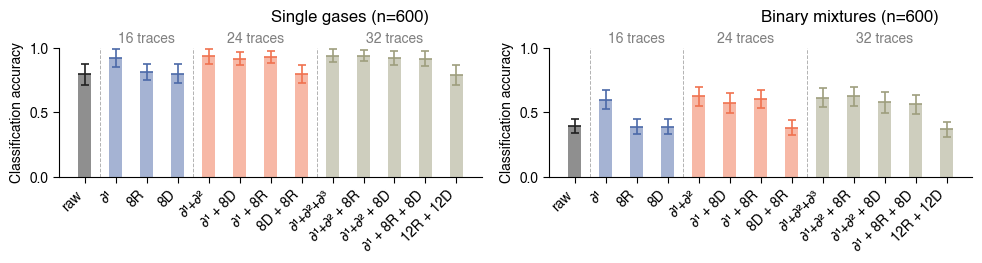

In [14]:
# --- Bar charts (side by side) ---
def plot_bar_chart(ax, table_data, title):
    groups = [
        (configs_8,  'C4', None),
        (configs_16, 'C0', '16 traces'),
        (configs_24, 'C1', '24 traces'),
        (configs_32, 'C2', '32 traces'),
    ]

    names = []
    means_list = []
    stds_list = []
    colors = []
    group_boundaries = []
    group_labels = []

    offset = 0
    for cfg, col, label in groups:
        start = offset
        for name in cfg:
            names.append(name)
            m, s = table_data[name]
            means_list.append(m)
            stds_list.append(s)
            colors.append(col)
            offset += 1
        if label is not None:
            group_labels.append(((start + offset - 1) / 2, label))
        group_boundaries.append(offset - 0.5)

    group_boundaries = group_boundaries[:-1]

    means = np.array(means_list)
    stds = np.array(stds_list)

    lw_thick = 1.2
    marker_width = 0.42
    x_pos = np.arange(len(names))

    for xi, mu, sd, col in zip(x_pos, means, stds, colors):
        ax.bar(xi, mu, color=col, width=marker_width, alpha=0.5, edgecolor='none', zorder=1)
        ax.hlines(mu, xi - marker_width / 2, xi + marker_width / 2,
                  color=col, linewidth=lw_thick, alpha=1.0, zorder=2)
        ax.errorbar(xi, [mu], yerr=[sd], c=col, fmt='none', clip_on=False,
                    capsize=3, elinewidth=lw_thick, capthick=lw_thick, alpha=1.0, zorder=2)

    for bx in group_boundaries:
        ax.axvline(bx, color='grey', linestyle='--', linewidth=0.7, alpha=0.6, zorder=0)

    for xc, label in group_labels:
        ax.text(xc, 1.02, label, transform=ax.get_xaxis_transform(),
                ha='center', va='bottom', fontsize=10, color='grey')

    ax.set_xticks(x_pos)
    ax.set_xticklabels(names, rotation=45, ha='right')
    ax.set_ylabel('Classification accuracy')
    ax.set_ylim(0, 1)
    ax.set_yticks([0, 0.5, 1])
    ax.spines[['top', 'right']].set_visible(False)
    ax.text(0.5, 1.2, title, transform=ax.transAxes,)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))
plot_bar_chart(ax1, table, 'Single gases (n=600)')
plot_bar_chart(ax2, table_mix, 'Binary mixtures (n=600)')
plt.tight_layout()
plt.show()